#  Salary Prediction - Comprehensive Exploratory Data Analysis (EDA)
**Author:** AI/ML Engineer Candidate  
**Project Goal:** Analyze key factors influencing employee salary levels (Age, Gender, Education Level, Job Title, Experience) to discover data insights, identify patterns, handle anomalies, and prepare clean data for Predictive Modeling.

---
###  Key Workflow & Structure:
1. **Environment & Data Loading**
2. **Initial Data Profiling & Structural Analysis**
3. **Data Cleaning & Preprocessing** (Missing Values, Duplicate Removal, Standardizing Categories)
4. **Univariate Analysis** (Feature Distributions, Outliers, Normality Check)
5. **Bivariate & Multivariate Analysis** (Correlation Analysis, Groupwise Aggregations)
6. **Feature Insights & Key Findings** (Resume-ready Portfolio Highlights)


## 1. Environment Setup & Data Loading

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling Setup for Professional Visualizations
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

# Robust Dataset Loading
file_path = os.path.join('..', 'dataset', 'Salary Data.csv') if os.path.exists('../dataset/Salary Data.csv') else os.path.join('dataset', 'Salary Data.csv')
df = pd.read_csv(file_path)

print(f"Raw Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Raw Dataset Shape: 375 rows x 6 columns


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## 2. Initial Data Profiling & Overview

In [8]:
# High-level dataset summary
print("=== DATA TYPES & NON-NULL COUNTS ===")
df.info()

print("=== SUMMARY STATISTICS (NUMERICAL) ===")
display(df.describe().T)

print("=== SUMMARY STATISTICS (CATEGORICAL) ===")
display(df.describe(include=['O']).T)


=== DATA TYPES & NON-NULL COUNTS ===
<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 30.8 KB
=== SUMMARY STATISTICS (NUMERICAL) ===


,count,mean,std,min,25%,50%,75%,max
Age,373.0,37.431635,7.069073,23.0,31.0,36.0,44.0,53.0
Years of Experience,373.0,10.030831,6.557007,0.0,4.0,9.0,15.0,25.0
Salary,373.0,100577.345845,48240.013482,350.0,55000.0,95000.0,140000.0,250000.0


=== SUMMARY STATISTICS (CATEGORICAL) ===


C:\Users\lenovo\AppData\Local\Temp\ipykernel_17480\2972505427.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['O']).T)


,count,unique,top,freq
Gender,373,2,Male,194
Education Level,373,3,Bachelor's,224
Job Title,373,174,Director of Marketing,12


## 3. Data Cleaning & Anomaly Resolution

In [9]:
# 3.1 Missing Value Inspection
print("=== MISSING VALUE ANALYSIS ===")
null_counts = df.isnull().sum()
print(null_counts)

# Display blank rows if any
if df.isnull().any().any():
    print("Blank Rows:")
    display(df[df.isnull().any(axis=1)])
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Successfully dropped missing rows. Clean Shape: {df.shape}")

# 3.2 Duplicate Analysis
dup_count = df.duplicated().sum()
dup_pct = (dup_count / len(df)) * 100
print(f"Duplicate Rows Detected: {dup_count} ({dup_pct:.2f}%)")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Deduplicated Dataset Shape: {df.shape}")


=== MISSING VALUE ANALYSIS ===
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64
Blank Rows:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN


Successfully dropped missing rows. Clean Shape: (373, 6)
Duplicate Rows Detected: 49 (13.14%)
Deduplicated Dataset Shape: (324, 6)


In [10]:
# 3.3 Standardize Categorical Columns
print("Unique Education Levels before cleaning:", df['Education Level'].unique())
print("Unique Genders:", df['Gender'].unique())

# Clean trailing whitespace
df['Education Level'] = df['Education Level'].str.strip()
df['Gender'] = df['Gender'].str.strip()

print("Value Counts for Education Level:")
display(df['Education Level'].value_counts())


Unique Education Levels before cleaning: <ArrowStringArray>
['Bachelor's', 'Master's', 'PhD']
Length: 3, dtype: str
Unique Genders: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Value Counts for Education Level:


Education Level
Bachelor's    191
Master's       91
PhD            42
Name: count, dtype: int64

## 4. Univariate Analysis (Distributions & Boxplots)

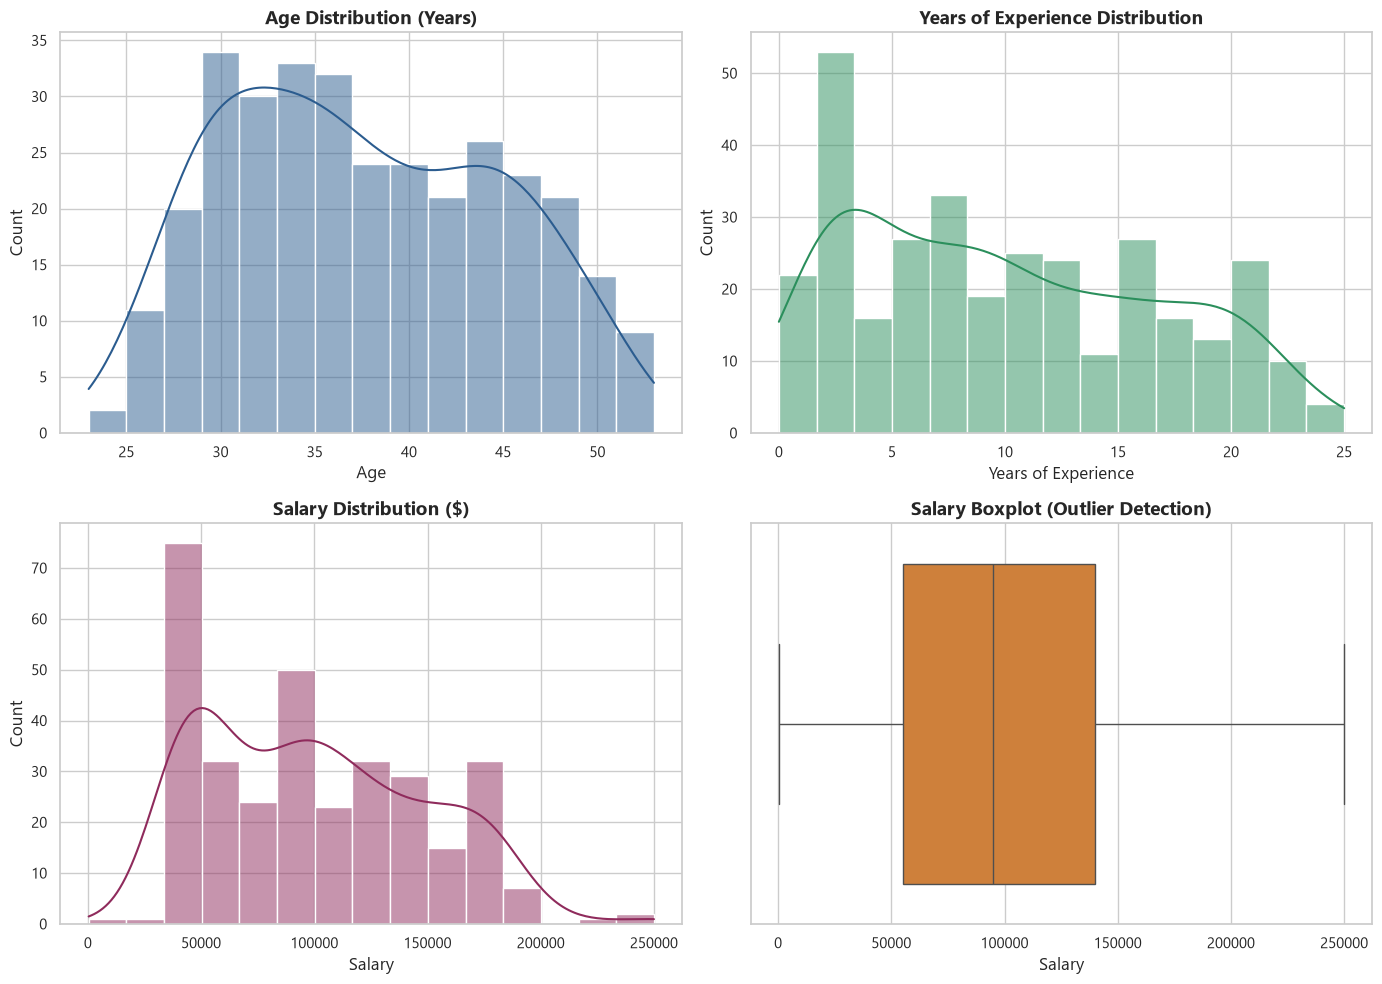

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0,0], color='#2b5c8f', bins=15)
axes[0,0].set_title('Age Distribution (Years)')

# Experience Distribution
sns.histplot(df['Years of Experience'], kde=True, ax=axes[0,1], color='#2b8f5c', bins=15)
axes[0,1].set_title('Years of Experience Distribution')

# Salary Target Distribution
sns.histplot(df['Salary'], kde=True, ax=axes[1,0], color='#8f2b5c', bins=15)
axes[1,0].set_title('Salary Distribution ($)')

# Boxplot for Salary (Outlier Check)
sns.boxplot(x=df['Salary'], ax=axes[1,1], color='#e67e22')
axes[1,1].set_title('Salary Boxplot (Outlier Detection)')

plt.tight_layout()
plt.show()


### Categorical Breakdown

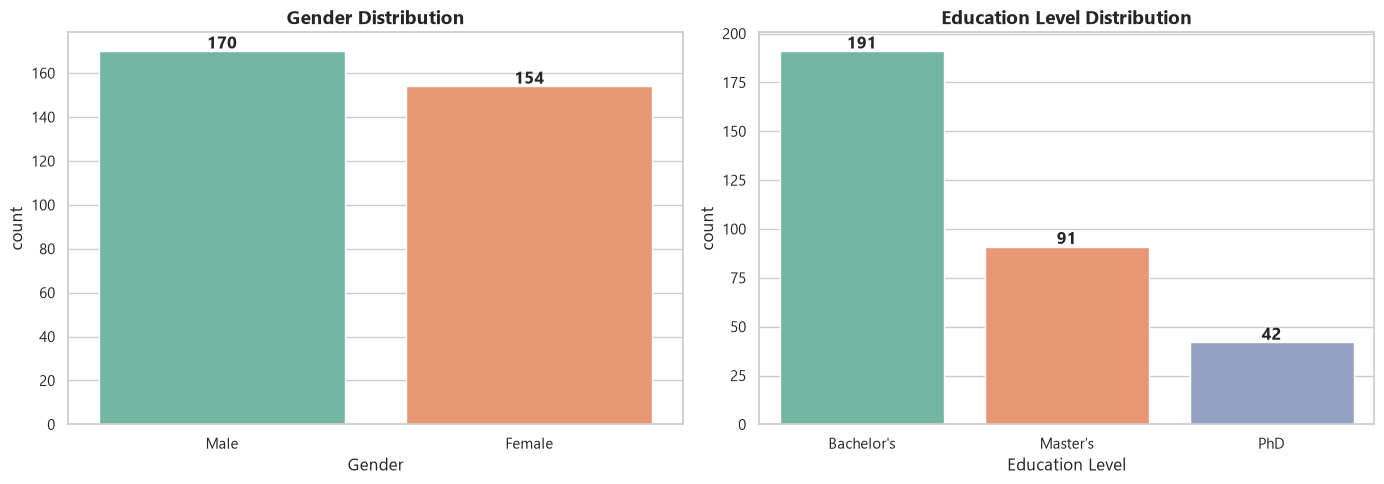

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender Breakdown
sns.countplot(data=df, x='Gender', hue='Gender', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Gender Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# Education Level Breakdown
sns.countplot(data=df, x='Education Level', hue='Education Level', ax=axes[1], palette='Set2', order=df['Education Level'].value_counts().index, legend=False)
axes[1].set_title('Education Level Distribution')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Bivariate & Multivariate Analysis

### 5.1 Salary vs. Experience & Age

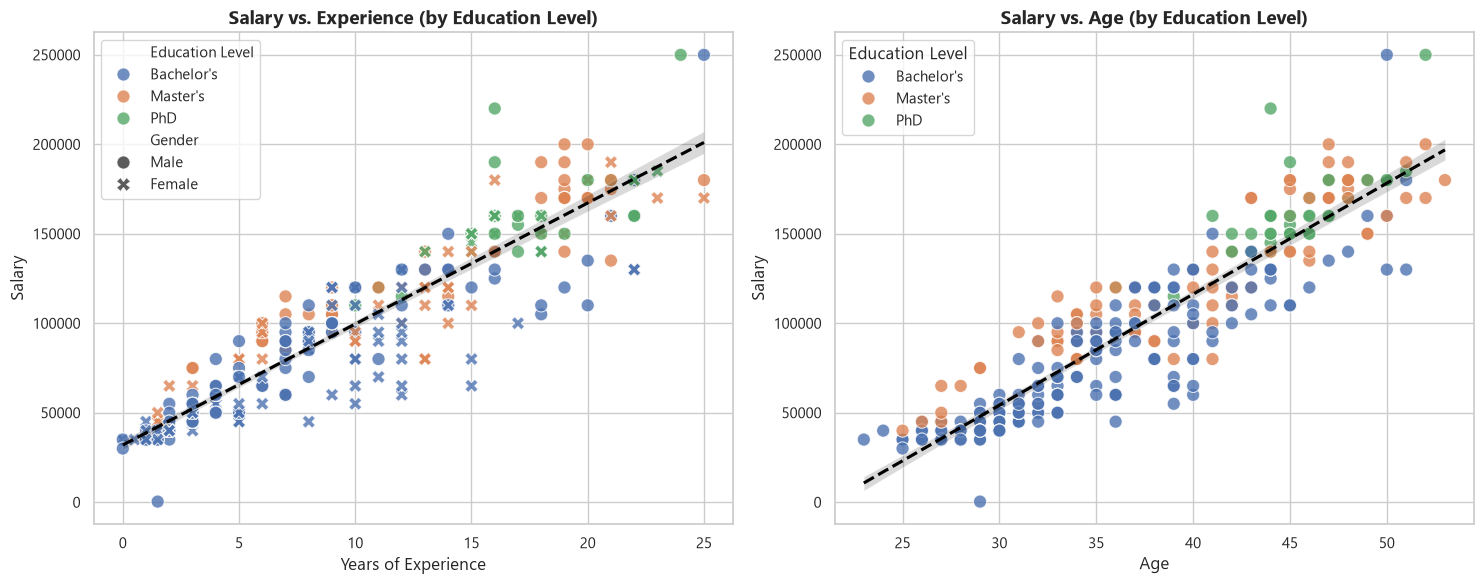

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Experience vs Salary
sns.scatterplot(data=df, x='Years of Experience', y='Salary', hue='Education Level', style='Gender', s=90, alpha=0.8, ax=axes[0], palette='deep')
sns.regplot(data=df, x='Years of Experience', y='Salary', scatter=False, ax=axes[0], color='black', line_kws={'linestyle':'--'})
axes[0].set_title('Salary vs. Experience (by Education Level)')

# Age vs Salary
sns.scatterplot(data=df, x='Age', y='Salary', hue='Education Level', s=90, alpha=0.8, ax=axes[1], palette='deep')
sns.regplot(data=df, x='Age', y='Salary', scatter=False, ax=axes[1], color='black', line_kws={'linestyle':'--'})
axes[1].set_title('Salary vs. Age (by Education Level)')

plt.tight_layout()
plt.show()


### 5.2 Salary Disparity by Education & Gender

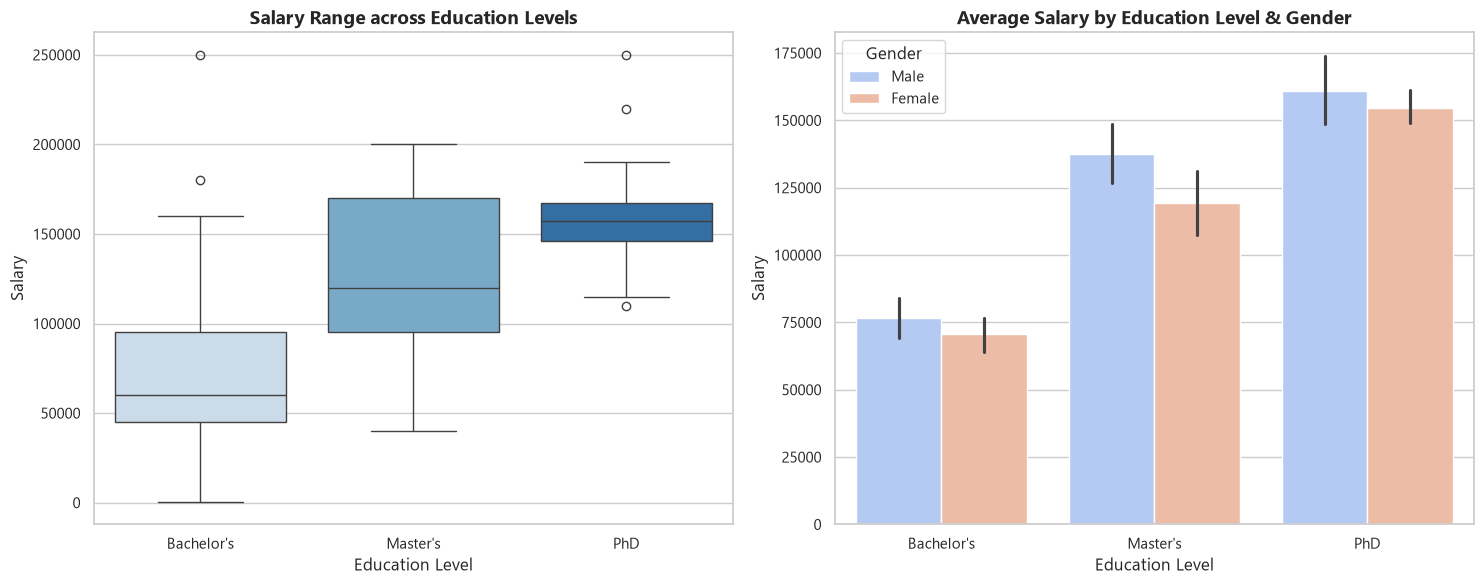

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Salary Range by Education Level
sns.boxplot(data=df, x='Education Level', y='Salary', hue='Education Level', palette='Blues', order=df.groupby('Education Level')['Salary'].median().sort_values().index, ax=axes[0], legend=False)
axes[0].set_title('Salary Range across Education Levels')

# Salary by Education & Gender
sns.barplot(data=df, x='Education Level', y='Salary', hue='Gender', palette='coolwarm', ax=axes[1])
axes[1].set_title('Average Salary by Education Level & Gender')

plt.tight_layout()
plt.show()


### 5.3 Top 10 Highest Average Paying Job Titles

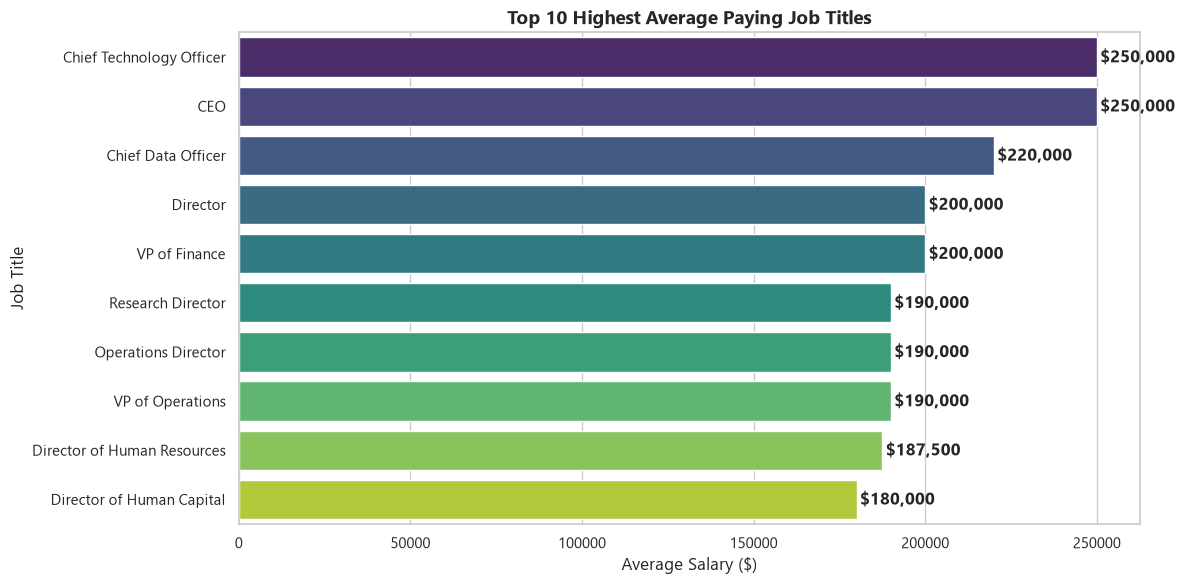

In [15]:
top_jobs = df.groupby('Job Title')['Salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, hue=top_jobs.index, palette='viridis', legend=False)
plt.title('Top 10 Highest Average Paying Job Titles')
plt.xlabel('Average Salary ($)')
plt.ylabel('Job Title')

for i, v in enumerate(top_jobs.values):
    plt.text(v + 1000, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 5.4 Correlation Matrix Heatmap

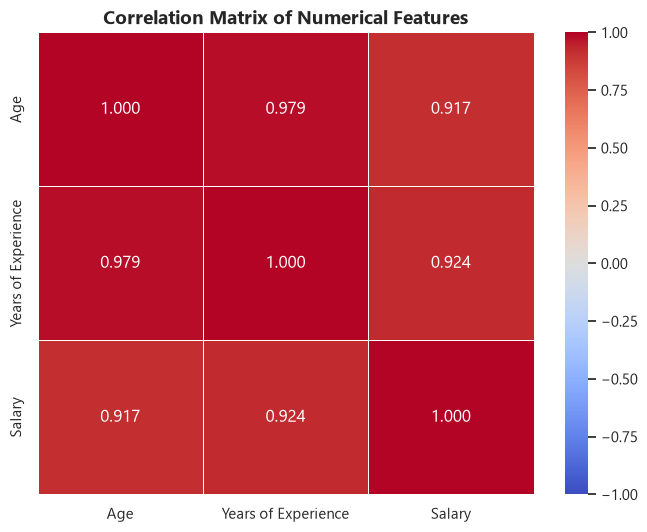

In [16]:
plt.figure(figsize=(8, 6))
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
